# **i. Introduction**

## This program is designed to make an analysis on the topic of Pizza Sales in 2015

# **ii. Problem Statement and Dataset Description**

URL DASHBOARD: https://www.kaggle.com/datasets/rhonarosecortez/pizza-sales-dataset

## Problem Statement

The pizza restaurant experienced a decline in sales during the first two months of the year. As a Data Analyst, I conducted a comprehensive analysis of the 2015 pizza sales data to identify performance trends, uncover key revenue drivers, and generate actionable insights. The results of this analysis are intended to support the Marketing Team in developing targeted strategies to increase profitability and improve overall sales performance.

- Specific:
    Develop a data-driven strategy to increase overall pizza sales performance.

- Measureable:
    Increase total revenue by 7%, measured using Gross Merchandise Value (GMV) and Profit.

- Achievable:
    Based on the pizza sales analysis, the following actions can be implemented:

    - Maintain and optimize inventory for the best-selling pizza categories and variants.
    - Increase unit sales across all pizza categories through targeted campaigns.
    - Provide data-backed promotional recommendations to the Marketing Division.

- Relevant:
    If the company does not address the current sales performance trends, it may face continued revenue decline and reduced profitability.

- Time bound:
    Achieve a measurable increase in revenue and profit within the third month after strategy implementation.

Metric: Gross Merchandise Value and Profit

Audience: Marketing Division


**Summary**:
    
    This project aims to develop a data-driven strategy to increase pizza sales revenue by 7% through comprehensive sales analysis using Python.

    The strategy focuses on optimizing top-performing product categories, improving sales volume across all segments, and delivering actionable promotional insights to the Marketing Division.

    By implementing these recommendations within a three-month period, the company is expected to improve Gross Merchandise Value (GMV) and overall profitability while mitigating the risk of further financial losses.

## 5W + 1H:



1. Which Pizza Category had the highest sales?
2. On which day were Pizzas sold the most?
3. How do Pizza sales differ each month?
4. Which month recorded the highest total pizza sales?
5. Are there any patterns in the quantity of pizzas sold each month?
6. What was the total monthly revenue for the entire year?
7. What is the relationship between monthly revenue and the quantity of pizzas sold?
8. How many pizzas were sold by size?
9. Is the quantity sold normally distributed?
10. Are there significant differences in the mean quantity sold among pizza categories?

# **iii. Data Loading**

In [ ]:
# Import Libraries
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

data = pd.read_csv('Pizza Sales Dataset.csv')

data

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_day,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,Thursday,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,Thursday,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,Thursday,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,Thursday,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,Thursday,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,12/31/2015,Thursday,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,12/31/2015,Thursday,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,12/31/2015,Thursday,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,12/31/2015,Thursday,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [2]:
# Make dataframe copy
df = data.copy()

df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_day,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,1/1/2015,Thursday,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,1/1/2015,Thursday,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,1/1/2015,Thursday,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,1/1/2015,Thursday,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,1/1/2015,Thursday,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,12/31/2015,Thursday,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,12/31/2015,Thursday,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,12/31/2015,Thursday,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,12/31/2015,Thursday,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


# **iv. Data Cleaning**

In [3]:
# Check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_day          48620 non-null  object 
 6   order_time         48620 non-null  object 
 7   unit_price         48620 non-null  float64
 8   total_price        48620 non-null  float64
 9   pizza_size         48620 non-null  object 
 10  pizza_category     48620 non-null  object 
 11  pizza_ingredients  48620 non-null  object 
 12  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 4.8+ MB


In [4]:
# Check missing values
df.isnull().sum()

pizza_id             0
order_id             0
pizza_name_id        0
quantity             0
order_date           0
order_day            0
order_time           0
unit_price           0
total_price          0
pizza_size           0
pizza_category       0
pizza_ingredients    0
pizza_name           0
dtype: int64

# **v. Exploration and Analysis**

In [5]:
# Check the unique values in the 'pizza_category' column
df['pizza_category'].unique().tolist()

['Classic', 'Veggie', 'Supreme', 'Chicken']

In [6]:
# Convert the data type of the 'order_date' column
df['order_date'] = pd.to_datetime(df['order_date'])

In [7]:
# Create a filtered DataFrame with selected relevant columns
eda = df[['order_date','order_day','pizza_name','quantity','unit_price', 'total_price', 'pizza_size', 'pizza_category']]

eda

,order_date,order_day,pizza_name,quantity,unit_price,total_price,pizza_size,pizza_category
0,2015-01-01,Thursday,The Hawaiian Pizza,1,13.25,13.25,M,Classic
1,2015-01-01,Thursday,The Classic Deluxe Pizza,1,16.00,16.00,M,Classic
2,2015-01-01,Thursday,The Five Cheese Pizza,1,18.50,18.50,L,Veggie
3,2015-01-01,Thursday,The Italian Supreme Pizza,1,20.75,20.75,L,Supreme
4,2015-01-01,Thursday,The Mexicana Pizza,1,16.00,16.00,M,Veggie
...,...,...,...,...,...,...,...,...
48615,2015-12-31,Thursday,The Chicken Alfredo Pizza,1,16.75,16.75,M,Chicken
48616,2015-12-31,Thursday,The Four Cheese Pizza,1,17.95,17.95,L,Veggie
48617,2015-12-31,Thursday,The Napolitana Pizza,1,12.00,12.00,S,Classic
48618,2015-12-31,Thursday,The Mexicana Pizza,1,20.25,20.25,L,Veggie


In [8]:
# Convert data type
eda['order_date'] = eda['order_date'].astype('datetime64[ns]')

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/1815652654.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['order_date'] = eda['order_date'].astype('datetime64[ns]')


In [9]:
# Make sure data type already converted
eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_date      48620 non-null  datetime64[ns]
 1   order_day       48620 non-null  object        
 2   pizza_name      48620 non-null  object        
 3   quantity        48620 non-null  int64         
 4   unit_price      48620 non-null  float64       
 5   total_price     48620 non-null  float64       
 6   pizza_size      48620 non-null  object        
 7   pizza_category  48620 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 3.0+ MB


In [10]:
# Convert data type
eda['Month'] = eda['order_date'].dt.month

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/3091661179.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['Month'] = eda['order_date'].dt.month


In [11]:
# Replace month name
eda['MonthName'] = eda['Month'].replace({1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June",
                                       7:"July", 8:"August", 9:"September", 10:"October", 11:"November", 12:"December"})

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/2443701778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['MonthName'] = eda['Month'].replace({1:"January", 2:"February", 3:"March", 4:"April", 5:"May", 6:"June",


In [12]:
# Make new column to count revenue
eda['Revenue'] = eda['quantity'] * eda['total_price']

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/3987519560.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['Revenue'] = eda['quantity'] * eda['total_price']


In [13]:
# Create a new DataFrame after cleaning the columns
eda

,order_date,order_day,pizza_name,quantity,unit_price,total_price,pizza_size,pizza_category,Month,MonthName,Revenue
0,2015-01-01,Thursday,The Hawaiian Pizza,1,13.25,13.25,M,Classic,1,January,13.25
1,2015-01-01,Thursday,The Classic Deluxe Pizza,1,16.00,16.00,M,Classic,1,January,16.00
2,2015-01-01,Thursday,The Five Cheese Pizza,1,18.50,18.50,L,Veggie,1,January,18.50
3,2015-01-01,Thursday,The Italian Supreme Pizza,1,20.75,20.75,L,Supreme,1,January,20.75
4,2015-01-01,Thursday,The Mexicana Pizza,1,16.00,16.00,M,Veggie,1,January,16.00
...,...,...,...,...,...,...,...,...,...,...,...
48615,2015-12-31,Thursday,The Chicken Alfredo Pizza,1,16.75,16.75,M,Chicken,12,December,16.75
48616,2015-12-31,Thursday,The Four Cheese Pizza,1,17.95,17.95,L,Veggie,12,December,17.95
48617,2015-12-31,Thursday,The Napolitana Pizza,1,12.00,12.00,S,Classic,12,December,12.00
48618,2015-12-31,Thursday,The Mexicana Pizza,1,20.25,20.25,L,Veggie,12,December,20.25


In [14]:
# Export the cleaned DataFrame to a new file
eda.to_csv('P0M1_Farras_Annisa_dataset.csv', index=False)

In [15]:
# Re-order column
SizeOrder = ['S', 'M', 'L', 'XL', 'XXL']
DayOrder = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MonthOrder = ['January', 'February', 'March', 'April', 'May', 'June',
                                       'July', 'August', 'September', 'October', 'November', 'December']

eda['pizza_size'] = pd.Categorical(eda['pizza_size'], categories=SizeOrder, ordered=True)
eda['order_day'] = pd.Categorical(eda['order_day'], categories=DayOrder, ordered=True)
eda['MonthName'] = pd.Categorical(eda['MonthName'], categories=MonthOrder, ordered=True)

/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/2777958089.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['pizza_size'] = pd.Categorical(eda['pizza_size'], categories=SizeOrder, ordered=True)
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/2777958089.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda['order_day'] = pd.Categorical(eda['order_day'], categories=DayOrder, ordered=True)
/var/folders/7l/8n2lxy7s00x2n3yc9gxj78bh0000gn/T/ipykernel_15852/2777958089.py:

## Best-Selling Pizza Category

In [16]:
# Count pizza by category
ClassicperYear = eda.loc[(eda['pizza_category'] == 'Classic'), 'quantity'].sum()

print("Total Classic pizza sales:", ClassicperYear)

VeggieperYear = eda.loc[(eda['pizza_category'] == 'Veggie'), 'quantity'].sum()

print("Total Veggie pizza sales:", VeggieperYear)

SupremeperYear = eda.loc[(eda['pizza_category'] == 'Supreme'), 'quantity'].sum()

print("Total Supreme pizza sales:", SupremeperYear)

ChickenperYear = eda.loc[(eda['pizza_category'] == 'Chicken'), 'quantity'].sum()

print("Total Chicken pizza sales:", ChickenperYear)


CategorySalesperYear = eda.groupby('pizza_category')['quantity'].sum().reset_index()

Total Classic pizza sales: 14888
Total Veggie pizza sales: 11649
Total Supreme pizza sales: 11987
Total Chicken pizza sales: 11050


In [17]:
# Make a visualization Best-Selling Pizza Category with plotly
fig = px.pie(
    CategorySalesperYear,
    names='pizza_category', 
    values='quantity',     
    title='Best-Selling Pizza Category',
    color_discrete_sequence=px.colors.qualitative.Vivid,  
)


fig.update_traces(
    sort=False, 
    direction='clockwise', 
    textinfo='percent+label', 
    pull=[0.02] * len(CategorySalesperYear))  

fig.update_layout(
    uniformtext_minsize=12, 
    uniformtext_mode='hide', 
    showlegend=False,         
)

fig.show()

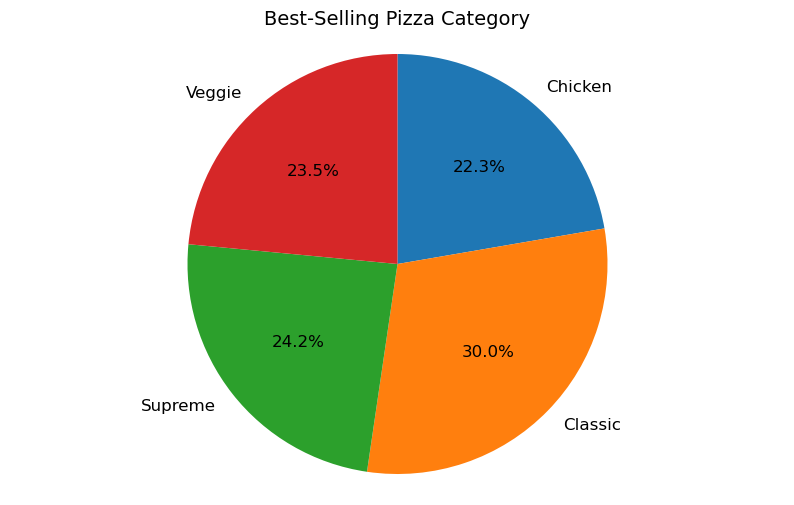

In [18]:
# Make a visualization Best-Selling Pizza Category with matplotlib
labels = CategorySalesperYear['pizza_category']
sizes = CategorySalesperYear['quantity']


fig, ax = plt.subplots(figsize=(10, 6))

ax.pie(
    sizes,
    labels=labels,                 
    autopct='%1.1f%%',             
    startangle=90,                 
    counterclock=False,            
    textprops={'fontsize': 12}
)

ax.set_title("Best-Selling Pizza Category", fontsize=14)

ax.axis('equal') 

plt.show()

### Based on the chart, the Classic category recorded the highest sales among all pizza categories

## Total Pizza Sales by Day

In [19]:
# Calculate total number of pizzas sold for each day
MondayperYear = eda.loc[(eda['order_day'] == 'Monday'), 'quantity'].sum()

print("Total pizzas sold on Monday:", MondayperYear)

TuesdayperYear = eda.loc[(eda['order_day'] == 'Tuesday'), 'quantity'].sum()

print("Total pizzas sold on Tuesday:", TuesdayperYear)

WednesdayperYear = eda.loc[(eda['order_day'] == 'Wednesday'), 'quantity'].sum()

print("Total pizzas sold on Wednesday:", WednesdayperYear)

ThursdayperYear = eda.loc[(eda['order_day'] == 'Thursday'), 'quantity'].sum()

print("Total pizzas sold on Thursday:", ThursdayperYear)

FridayperYear = eda.loc[(eda['order_day'] == 'Friday'), 'quantity'].sum()

print("Total pizzas sold on Friday:", FridayperYear)

SaturdayperYear = eda.loc[(eda['order_day'] == 'Saturday'), 'quantity'].sum()

print("Total pizzas sold on Saturday:", SaturdayperYear)

SundayperYear = eda.loc[(eda['order_day'] == 'Sunday'), 'quantity'].sum()

print("Total pizzas sold on Sunday:", SundayperYear)

DaySalesperYear = eda.groupby('order_day')['quantity'].sum().reset_index()

Total pizzas sold on Monday: 6485
Total pizzas sold on Tuesday: 6895
Total pizzas sold on Wednesday: 6946
Total pizzas sold on Thursday: 7478
Total pizzas sold on Friday: 8242
Total pizzas sold on Saturday: 7493
Total pizzas sold on Sunday: 6035


In [20]:
# Make a visualization total pizza sold by day with plotly
fig = px.line(DaySalesperYear, x="order_day", y="quantity", title='Sales per Year Based on Day')
fig.update_xaxes(tickangle=90)
fig.update_layout(xaxis_title='Day', yaxis_title='Quantity',  title_x=0.5)
fig.show()

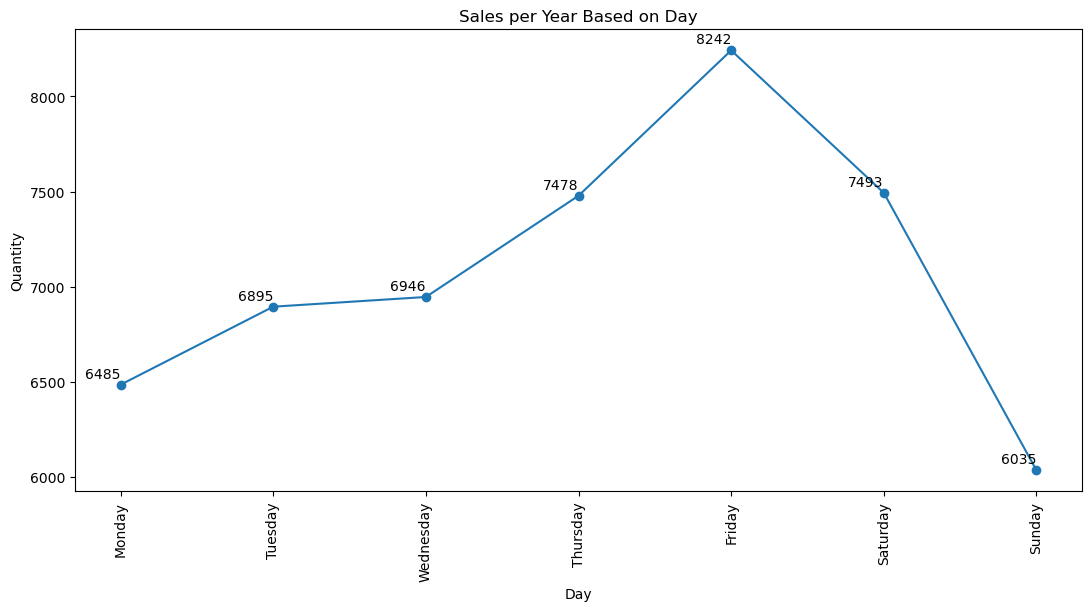

In [21]:
# Make a visualization total pizza sold by day with matplotlib
x = DaySalesperYear['order_day']
y = DaySalesperYear['quantity']

plt.figure(figsize=(13, 6))

plt.plot(x, y, marker='o')

for i in range(len(x)):
    plt.annotate(
        y.iloc[i], 
        (x.iloc[i], y.iloc[i]),
        textcoords="offset points",
        xytext=(0,5),
        ha='right'
    )

plt.title('Sales per Year Based on Day', loc='center')
plt.xlabel('Day')
plt.ylabel('Quantity')

plt.xticks(rotation=90)


plt.show()


### Based on the chart, pizza sales were highest on Friday

## Total Pizzas Sold by Month

In [22]:
# Calculate total pizzas sold for each month
JanuaryperYear = eda.loc[(eda['MonthName'] == 'January'), 'quantity'].sum()

print("Total pizzas sold on January:", JanuaryperYear)


FebruaryperYear = eda.loc[(eda['MonthName'] == 'February'), 'quantity'].sum()

print("Total pizzas sold on February:", FebruaryperYear)


MarchperYear = eda.loc[(eda['MonthName'] == 'March'), 'quantity'].sum()

print("Total pizzas sold on March:", MarchperYear)


AprilperYear = eda.loc[(eda['MonthName'] == 'April'), 'quantity'].sum()

print("Total pizzas sold on April:", AprilperYear)


MayperYear = eda.loc[(eda['MonthName'] == 'May'), 'quantity'].sum()

print("Total pizzas sold on May:", MayperYear)


JuneperYear = eda.loc[(eda['MonthName'] == 'June'), 'quantity'].sum()

print("Total pizzas sold on June:", JuneperYear)


JulyperYear = eda.loc[(eda['MonthName'] == 'July'), 'quantity'].sum()

print("Total pizzas sold on July:", JulyperYear)


AugustperYear = eda.loc[(eda['MonthName'] == 'August'), 'quantity'].sum()

print("Total pizzas sold on August:", AugustperYear)


SeptemberperYear = eda.loc[(eda['MonthName'] == 'September'), 'quantity'].sum()

print("Total pizzas sold on September:", SeptemberperYear)


OctoberperYear = eda.loc[(eda['MonthName'] == 'October'), 'quantity'].sum()

print("Total pizzas sold on October:", OctoberperYear)


NovemberperYear = eda.loc[(eda['MonthName'] == 'November'), 'quantity'].sum()

print("Total pizzas sold on November:", NovemberperYear)


DecemberperYear = eda.loc[(eda['MonthName'] == 'December'), 'quantity'].sum()

print("Total pizzas sold on December:", DecemberperYear)


Total pizzas sold on January: 4232
Total pizzas sold on February: 3961
Total pizzas sold on March: 4261
Total pizzas sold on April: 4151
Total pizzas sold on May: 4328
Total pizzas sold on June: 4107
Total pizzas sold on July: 4392
Total pizzas sold on August: 4168
Total pizzas sold on September: 3890
Total pizzas sold on October: 3883
Total pizzas sold on November: 4266
Total pizzas sold on December: 3935


In [23]:
# Calculate total pizzas sold for each month for visualization
SalesperMonth = eda.groupby('MonthName')['quantity'].sum().reset_index()

In [24]:
# Make a visualization of Total Pizzas Sold by Month with plotly

fig = px.bar(
    SalesperMonth,
    x='MonthName',
    y='quantity',
    title='Total Pizzas Sold by Month',
    color='MonthName',
    color_discrete_sequence=px.colors.qualitative.Vivid
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black')
)
fig.show()

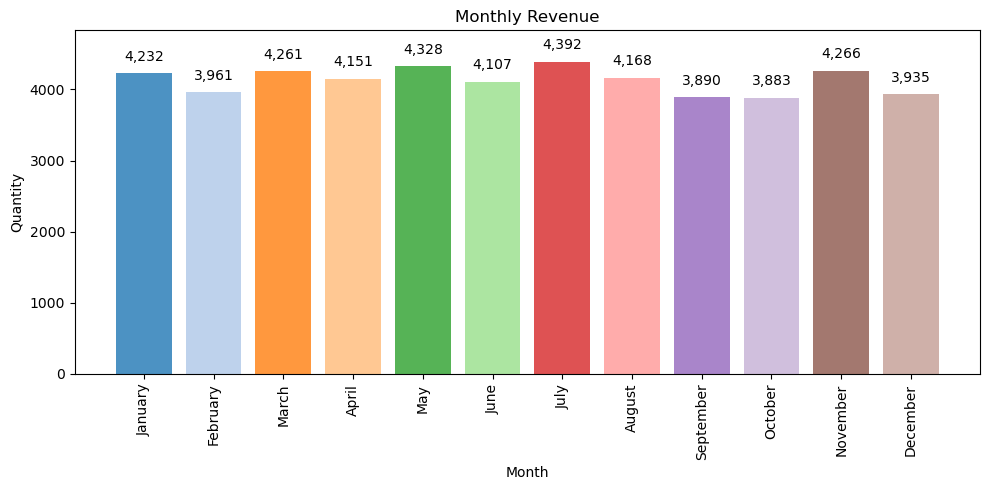

In [25]:
# Make a visualization of Total Pizzas Sold by Month with matplotlib
months = SalesperMonth['MonthName']
values = SalesperMonth['quantity']


bar_colors = plt.cm.tab20.colors[:len(months)]


plt.figure(figsize=(10, 5))


bars = plt.bar(months, values, color=bar_colors, alpha=0.8)


plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Quantity')


plt.xticks(rotation=90)


y_max = max(values)
plt.ylim(0, y_max * 1.1)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + y_max * 0.03,
        f'{int(height):,}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Based on the chart, pizza sales were highest on July

## Monthly Revenue

In [26]:
# Calculate revenue for each month
RevenueJanuary = eda.loc[(eda['MonthName'] == 'January'), 'total_price'].sum()

print("Revenue on January:", RevenueJanuary)


RevenueFebruary = eda.loc[(eda['MonthName'] == 'February'), 'total_price'].sum()

print("Revenue on February:", RevenueFebruary)


RevenueMarch = eda.loc[(eda['MonthName'] == 'March'), 'total_price'].sum()

print("Revenue on March:", RevenueMarch)


RevenueApril = eda.loc[(eda['MonthName'] == 'April'), 'total_price'].sum()

print("Revenue on April:", RevenueApril)


RevenueMay = eda.loc[(eda['MonthName'] == 'May'), 'total_price'].sum()

print("Revenue on May:", RevenueMay)


RevenueJune = eda.loc[(eda['MonthName'] == 'June'), 'total_price'].sum()

print("Revenue on June:", RevenueJune)


RevenueJuly = eda.loc[(eda['MonthName'] == 'July'), 'total_price'].sum()

print("Revenue on July:", RevenueJuly)


RevenueAugust = eda.loc[(eda['MonthName'] == 'August'), 'total_price'].sum()

print("Revenue on August:", RevenueAugust)


RevenueSeptember = eda.loc[(eda['MonthName'] == 'September'), 'total_price'].sum()

print("Revenue on September:", RevenueSeptember)


RevenueOctober = eda.loc[(eda['MonthName'] == 'October'), 'total_price'].sum()

print("Revenue on October:", RevenueOctober)


RevenueNovember = eda.loc[(eda['MonthName'] == 'November'), 'total_price'].sum()

print("Revenue on November:", RevenueNovember)


RevenueDecember = eda.loc[(eda['MonthName'] == 'December'), 'total_price'].sum()

print("Revenue on December:", RevenueDecember)


RevenueperMonth = eda.groupby('MonthName')['total_price'].sum().reset_index()

Revenue on January: 69793.3
Revenue on February: 65159.6
Revenue on March: 70397.09999999999
Revenue on April: 68736.80000000002
Revenue on May: 71402.75
Revenue on June: 68230.2
Revenue on July: 72557.9
Revenue on August: 68278.25
Revenue on September: 64180.049999999996
Revenue on October: 64027.600000000006
Revenue on November: 70395.35
Revenue on December: 64701.15


In [27]:
# Make a vizualisation of monthly revenue with plotly

fig = px.bar(
    RevenueperMonth,
    x='MonthName',
    y='total_price',
    title='Total Revenue by Month',
    color='MonthName',
    color_discrete_sequence=px.colors.qualitative.Vivid
)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(color='black'),
     xaxis_title='Month',
    yaxis_title='Revenue'
)
fig.show()

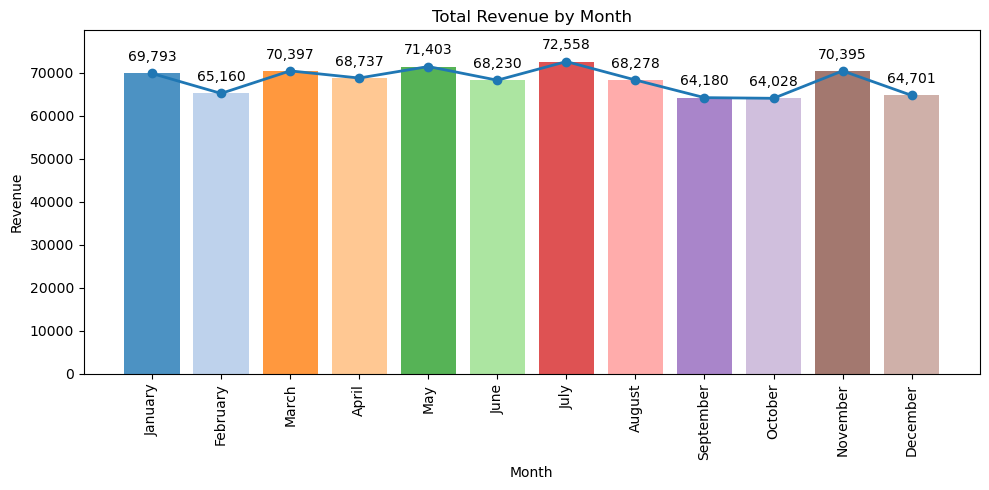

In [28]:
# Make a bar chart of revenue by month with matplotlib

months = RevenueperMonth['MonthName']
values = RevenueperMonth['total_price']


bar_colors = plt.cm.tab20.colors[:len(months)]


plt.figure(figsize=(10, 5))


bars = plt.bar(months, values, color=bar_colors, alpha=0.8)


plt.plot(months, values, marker='o', linewidth=2)


plt.title('Total Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Revenue')



plt.xticks(rotation=90)


y_max = max(values)
plt.ylim(0, max(values) * 1.1)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + y_max * 0.03,     
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()


### Based on the chart, pizza sales peaked in July and reached their lowest point in October. The quantity of pizzas sold fluctuated throughout the year, from January to December

In [29]:
# Re-order pizza size
SizeOrder = ['S', 'M', 'L', 'XL', 'XXL']

# Calculate pizzas sold by size
SizeS = eda.loc[(eda['pizza_size'] == 'S') , 'quantity'].sum()

print("Total S-sized Pizzas sold:", SizeS)


SizeM = eda.loc[(eda['pizza_size'] == 'M'), 'quantity'].sum()

print("Total M-sized Pizzas sold:", SizeM)


SizeL = eda.loc[(eda['pizza_size'] == 'L'), 'quantity'].sum()

print("Total L-sized Pizzas sold", SizeL)


SizeXL = eda.loc[(eda['pizza_size'] == 'XL'), 'quantity'].sum()

print("Total XL-sized Pizzas sold:", SizeXL)


SizeXXL = eda.loc[(eda['pizza_size'] == 'XXL'), 'quantity'].sum()

print("Total XXL-sized Pizzas sold:", SizeXXL)


SizeSalesYear = df.groupby('pizza_size')['quantity'].sum().reset_index()

Total S-sized Pizzas sold: 14403
Total M-sized Pizzas sold: 15635
Total L-sized Pizzas sold 18956
Total XL-sized Pizzas sold: 552
Total XXL-sized Pizzas sold: 28


## Best-Selling Pizza Size

In [30]:
# Make a vizualisation of pizzas sold by size with plotly

# Sort data by quantity
SizeSalesYear = SizeSalesYear.sort_values(by='quantity', ascending=False)

fig = px.bar(
    SizeSalesYear,
    y='pizza_size',
    x='quantity',
    orientation='h',
    title='Best-Selling Pizza Size',
    color='pizza_size',
    color_discrete_sequence=px.colors.qualitative.Vivid
)

fig.update_layout(
    title_x=0.5,
    plot_bgcolor='white',
    paper_bgcolor='white',
    uniformtext_minsize=12,
    uniformtext_mode='hide',
    showlegend=False,
    xaxis_title='Number of Pizzas Sold',
    yaxis_title='Pizza Size'
)

fig.update_xaxes(tickformat=",")

fig.show()

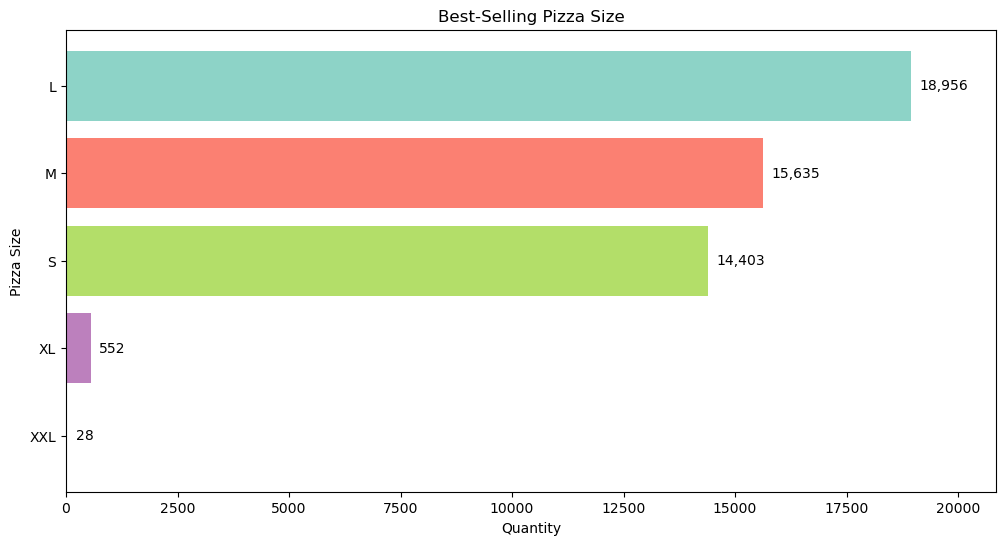

In [31]:
# Make a vizualisation of pizzas sold by size with matplotlib
plt.figure(figsize=(12, 6))


colors = plt.cm.Set3(np.linspace(0, 1, len(SizeSalesYear)))

bars = plt.barh(
    SizeSalesYear['pizza_size'],
    SizeSalesYear['quantity'],
    color=colors
)

plt.gca().invert_yaxis()


max_value = SizeSalesYear['quantity'].max()


for index, value in enumerate(SizeSalesYear['quantity']):
    plt.text(
        value + max_value * 0.01,   # small right offset
        index,
        f"{value:,}",
        va='center',
        ha='left'
    )


plt.xlim(0, max_value * 1.10)

plt.title('Best-Selling Pizza Size', loc='center')
plt.xlabel('Quantity')
plt.ylabel('Pizza Size')


plt.show()

### Based on the chart, the highest sales among all pizza size is L

## Descriptive Statistics

In [32]:
SalesbyDateEntireYear = df.groupby('order_date')['quantity'].sum()
SalesbyDateEntireYear

order_date
2015-01-01    162
2015-01-02    165
2015-01-03    158
2015-01-04    106
2015-01-05    125
             ... 
2015-12-27     89
2015-12-28    102
2015-12-29     80
2015-12-30     82
2015-12-31    178
Name: quantity, Length: 358, dtype: int64

In [33]:
# Count Average, Median, Mode, and Standar Deviation pizza sales
print('Pizza sales in Average:',SalesbyDateEntireYear.mean())
print('Median of Pizza sales:',SalesbyDateEntireYear.median())
print('Mode of Pizza sales:',SalesbyDateEntireYear.mode().values[0])
print('Standard Deviation of Pizza sales:',SalesbyDateEntireYear.std())

Pizza sales in Average: 138.47486033519553
Median of Pizza sales: 136.0
Mode of Pizza sales: 136
Standard Deviation of Pizza sales: 24.428669026957206


### Based on the results above, the data are approximately normally distributed

In [34]:
# Count Skewness and Kurtosis
print(f"Skewness:", SalesbyDateEntireYear.skew())
print(f"Kurtosis:", SalesbyDateEntireYear.kurtosis())

Skewness: 1.3885659936977472
Kurtosis: 5.654136967206002


### The results above indicate that the distribution of pizza sales data is positively skewed and has heavier tails

## Inferential Statistics

### Are There Significantly Difference of Average Quantity sales Among Pizza Category?

H0: There is no significant difference in the mean quantity sold among pizza categories

H1: There is significant difference in the mean quantity sold among pizza categories

In [35]:
classic = eda[eda['pizza_category'] == 'Classic']['quantity']
veggie = eda[eda['pizza_category'] == 'Veggie']['quantity']
supreme = eda[eda['pizza_category'] == 'Supreme']['quantity']
chicken = eda[eda['pizza_category'] == 'Chicken']['quantity']

# One-way ANOVA
f_stat, p_value = stats.f_oneway(classic, veggie, supreme, chicken)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 2.848689079237419
P-value: 0.03598732006954901


### Based on the obtained p-value (p < 0.05), there is sufficient evidence to conclude that the mean sales quantity differs among pizza categories

# vi. Conclusion & Recommendation

## **Conclusion**

The analysis indicates that the Classic pizza category generated the highest sales among all categories, with size L being the most frequently purchased size. Sales performance shows clear temporal patterns, peaking on Fridays and in July, while reaching the lowest level in October.

Monthly sales volume fluctuated throughout the year, with a noticeable peak in mid-year (July). The distribution of sales quantity is approximately normal, although slightly positively skewed with heavier tails, indicating occasional high-demand periods.

Furthermore, the one-way ANOVA test (p < 0.05) confirms that there are statistically significant differences in mean sales quantity among pizza categories. This suggests that customer demand varies meaningfully across categories.

## **Recommendation**

- Leverage Top Performers:
   Since the Classic category and size L dominate sales, marketing campaigns should prioritize bundling, upselling, and promotional strategies centered around these high-performing products.

- Capitalize on Peak Periods:
   With sales peaking on Fridays and in July, targeted promotions, limited-time offers, and advertising spend should be intensified during these high-demand periods to maximize revenue.

- Address Low-Performing Periods:
   October shows the lowest sales volume. Strategic discount campaigns, loyalty rewards, or seasonal menu innovations can help stabilize revenue
   during slower months.

- Category-Based Strategy:
   Given the significant differences in average sales across categories, differentiated marketing strategies should be applied rather than a
   one-size-fits-all approach.

- Demand Forecasting:
   Since the data are approximately normally distributed with slight positive skewness, predictive modeling can be applied reliably to forecast demand and optimize inventory planning.